# Exploración de `movies`, `tags` y `ratings`

## 1. Introducción

Este notebook cruza las tres tablas del proyecto para responder una pregunta que ni
`movies_ratings.ipynb` ni un notebook centrado solo en `tags` podrían responder por separado:
**¿lo que la gente escribe sobre una película (sus etiquetas) se relaciona con cómo la califica?**

Concretamente:

* ¿Las películas más etiquetadas son también las más y mejor calificadas?
* ¿Las etiquetas coinciden con el género declarado de la película (por ejemplo, ¿lo etiquetado como
  "funny" es realmente Comedia)?
* ¿Qué palabras usa la gente para describir las películas mejor calificadas frente a las peor
  calificadas?

**Aviso sobre el origen de los datos (igual que en `movies_ratings.ipynb`):** `tags.csv` y
`movies.csv` son las **tablas completas y reales**, sin muestreo. Todo lo que involucra
**calificaciones** (`ratings.csv`) viene de `ratings_sample.csv`, una **muestra aleatoria sistemática
de 500 000 de las 32 000 205 calificaciones reales** (≈1.56 %). Esto significa que la "riqueza de
etiquetado" de una película (cuántos tags distintos tiene) es exacta, pero su número de calificaciones
y su calificación media son estimaciones basadas en la muestra.

## 2. Importación de librerías

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

## 3. Carga de datos

In [2]:
RUTA_MOVIES = "../../Datasets/ml-32m/movies.csv"
RUTA_TAGS = "../../Datasets/ml-32m/tags.csv"
RUTA_RATINGS_MUESTRA = "../../Datasets/ml-32m/ratings_sample.csv"

movies = pd.read_csv(RUTA_MOVIES)
tags = pd.read_csv(RUTA_TAGS)
ratings = pd.read_csv(RUTA_RATINGS_MUESTRA)

print(f"movies:  {movies.shape[0]:,} filas (catálogo completo)")
print(f"tags:    {tags.shape[0]:,} filas (tabla completa)")
print(f"ratings: {ratings.shape[0]:,} filas (muestra del dataset de 32 000 205 calificaciones reales)")

movies:  87,585 filas (catálogo completo)
tags:    2,000,072 filas (tabla completa)
ratings: 500,000 filas (muestra del dataset de 32 000 205 calificaciones reales)


## 4. Exploración inicial de `tags`

In [3]:
tags.info()
print()
tags.head(10)

<class 'pandas.DataFrame'>
RangeIndex: 2000072 entries, 0 to 2000071
Data columns (total 4 columns):
 #   Column     Dtype
---  ------     -----
 0   userId     int64
 1   movieId    int64
 2   tag        str  
 3   timestamp  int64
dtypes: int64(3), str(1)
memory usage: 61.0 MB



,userId,movieId,tag,timestamp
0,22,26479,Kevin Kline,1583038886
1,22,79592,misogyny,1581476297
2,22,247150,acrophobia,1622483469
3,34,2174,music,1249808064
4,34,2174,weird,1249808102
5,34,8623,Steve Martin,1249808497
6,55,5766,the killls and the score,1319322078
7,58,7451,bullying,1672551536
8,58,7451,clique,1672551510
9,58,7451,coming of age,1672551502


In [4]:
print(f"Nulos por columna:\n{tags.isnull().sum()}\n")
print(f"Filas con tag nulo: {tags['tag'].isna().sum()}")
print(f"Duplicados exactos (misma fila repetida): {tags.duplicated().sum()}")
print(f"Usuarios distintos que han etiquetado: {tags['userId'].nunique():,}")
print(f"Películas distintas con al menos un tag: {tags['movieId'].nunique():,} de "
      f"{movies.shape[0]:,} del catálogo")
print(f"Tags de texto distintos (sin normalizar): {tags['tag'].nunique():,}")

Nulos por columna:
userId        0
movieId       0
tag          17
timestamp     0
dtype: int64

Filas con tag nulo: 17


Duplicados exactos (misma fila repetida): 0
Usuarios distintos que han etiquetado: 15,848
Películas distintas con al menos un tag: 51,323 de 87,585 del catálogo
Tags de texto distintos (sin normalizar): 140,979


**Resultados:** hay 17 filas con `tag` nulo (menos del 0.001 % del total) — se eliminan, no aportan
información. El resto está sin duplicados exactos. 51 323 películas (de las 87 585 del catálogo)
tienen al menos una etiqueta puesta por algún usuario; 15 848 usuarios han etiquetado alguna vez.

**Conclusión:** la tabla está prácticamente limpia; solo requiere quitar los pocos nulos antes de
seguir.

### Unidad de observación

Cada fila de `tags` representa **un evento de etiquetado**: un usuario le puso una palabra o frase
libre a una película en un momento determinado. Un mismo usuario puede etiquetar la misma película más
de una vez con tags distintos, y la misma palabra puede repetirse escrita de formas distintas
(mayúsculas, espacios) porque es texto libre, no una categoría cerrada como el género.

## 5. Transformaciones

**Qué se hace:** se quitan las filas con `tag` nulo y se normaliza el texto del tag (minúsculas,
sin espacios sobrantes) para que "Sci-Fi", "sci-fi " y "Sci-fi" cuenten como la misma etiqueta.

**Por qué es necesaria:** sin esta normalización, cualquier conteo de "tags más frecuentes" o
comparación entre grupos subestimaría la frecuencia real de cada etiqueta al dividirla en variantes
de mayúsculas/espacios que en realidad significan lo mismo.

In [5]:
tags_limpio = tags.dropna(subset=["tag"]).copy()
tags_limpio["tag_norm"] = tags_limpio["tag"].str.strip().str.lower()

print(f"Filas tras quitar nulos: {tags_limpio.shape[0]:,}")
print(f"Tags únicos sin normalizar: {tags['tag'].nunique():,} -> "
      f"normalizados: {tags_limpio['tag_norm'].nunique():,} "
      f"({tags['tag'].nunique() - tags_limpio['tag_norm'].nunique():,} variantes fusionadas)")

Filas tras quitar nulos: 2,000,055


Tags únicos sin normalizar: 140,979 -> normalizados: 131,645 (9,334 variantes fusionadas)


In [6]:
movies["sin_genero"] = movies["genres"] == "(no genres listed)"
GENEROS = movies.loc[~movies["sin_genero"], "genres"].str.get_dummies("|").columns.tolist()
print(f"Géneros disponibles para las comparaciones de la sección 8: {GENEROS}")

Géneros disponibles para las comparaciones de la sección 8: ['Action', 'Adventure', 'Animation', 'Children', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'IMAX', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']


## 6. Cruce de las tres tablas y validación

**Qué se calcula:** se comprueba que las películas etiquetadas existan en `movies.csv` (huérfanos), y
se construye el perfil por película necesario para el resto del notebook: para cada película con al
menos una calificación en la muestra, se agrega su número de calificaciones y calificación media
(desde `ratings`), y por separado —sobre **toda** la tabla `tags`, sin muestreo— su número de tags
distintos ("riqueza de etiquetado").

In [7]:
huerfanas_tags = ~tags_limpio["movieId"].isin(movies["movieId"])
print(f"Tags cuya película no existe en movies.csv: {huerfanas_tags.sum()}")

riqueza_tags = tags_limpio.groupby("movieId")["tag_norm"].nunique().rename("n_tags_distintos")
aplicaciones_tags = tags_limpio.groupby("movieId").size().rename("n_aplicaciones_tag")

df_ratings = ratings.merge(movies, on="movieId", how="inner")
perfil = (
    df_ratings.groupby("movieId")
    .agg(title=("title", "first"), genres=("genres", "first"),
         sin_genero=("sin_genero", "first"),
         n_calificaciones=("rating", "size"), calificacion_media=("rating", "mean"))
    .reset_index()
)
perfil = perfil.merge(riqueza_tags, on="movieId", how="left").merge(aplicaciones_tags, on="movieId", how="left")
perfil["n_tags_distintos"] = perfil["n_tags_distintos"].fillna(0).astype(int)
perfil["n_aplicaciones_tag"] = perfil["n_aplicaciones_tag"].fillna(0).astype(int)

# Diccionario donde se guardan los p-valores para corregirlos al final (sección 9)
pruebas = {}

print(f"\nPerfil de películas (con al menos 1 calificación en la muestra): {len(perfil)}")
print(f"De esas, sin ningún tag en toda la tabla completa: {(perfil['n_tags_distintos'] == 0).sum()}")
perfil[["title", "n_calificaciones", "calificacion_media", "n_tags_distintos"]].head()

Tags cuya película no existe en movies.csv: 0



Perfil de películas (con al menos 1 calificación en la muestra): 21279
De esas, sin ningún tag en toda la tabla completa: 2281


,title,n_calificaciones,calificacion_media,n_tags_distintos
0,Toy Story (1995),1015,3.894089,423
1,Jumanji (1995),439,3.308656,346
2,Grumpier Old Men (1995),211,3.078199,23
3,Waiting to Exhale (1995),38,2.907895,9
4,Father of the Bride Part II (1995),206,3.087379,32


**Resultados:** cero tags huérfanos — todas las películas etiquetadas existen en el catálogo. De
las 21 279 películas con al menos una calificación en la muestra, 2 281 (10.7 %) no tienen ningún tag
en toda la tabla `tags.csv` completa.

**Conclusión:** el cruce es correcto. Es importante notar que "sin calificación en la muestra" (por
`ratings_sample`) y "sin tags" (por `tags.csv` completo) son dos cosas de naturaleza distinta: lo
primero es un efecto del muestreo, lo segundo es un hecho real sobre la película.

## 7. Nota metodológica: unidad de análisis

Igual que en `movies_ratings.ipynb`, la unidad de análisis para cualquier comparación entre
películas es la **película**, no la calificación ni el evento de etiquetado — de lo contrario, una
película con miles de tags o calificaciones pesaría artificialmente más que una con pocos.

Hay una asimetría adicional que conviene declarar de entrada: la **riqueza de etiquetado**
(`n_tags_distintos`) es un valor **exacto** porque viene de `tags.csv` completo, mientras que
`n_calificaciones` y `calificacion_media` son **estimaciones** por venir de la muestra. Cuando se
correlacionan ambas variables (sección 8.1), una es exacta y la otra no — la incertidumbre de la
correlación viene solo del lado de las calificaciones.

In [8]:
def holm(p_valores):
    """Corrección de Holm-Bonferroni para comparaciones múltiples."""
    ordenados = sorted(p_valores.items(), key=lambda par: par[1])
    m = len(ordenados)
    ajustados, maximo_previo = {}, 0.0
    for i, (nombre, p) in enumerate(ordenados):
        maximo_previo = max(maximo_previo, min(1.0, (m - i) * p))
        ajustados[nombre] = maximo_previo
    return ajustados

## 8. Exploración descriptiva de `tags`

In [9]:
top_tags = tags_limpio["tag_norm"].value_counts().head(20)
print(top_tags)

tag_norm
sci-fi                11457
atmospheric           10088
action                 9344
comedy                 9275
funny                  8088
surreal                7480
visually appealing     7253
based on a book        6733
twist ending           6600
romance                6229
dark comedy            6153
thought-provoking      6003
dystopia               5713
violence               5483
cinematography         5429
murder                 5238
social commentary      5201
fantasy                5154
thriller               5050
quirky                 4954
Name: count, dtype: int64


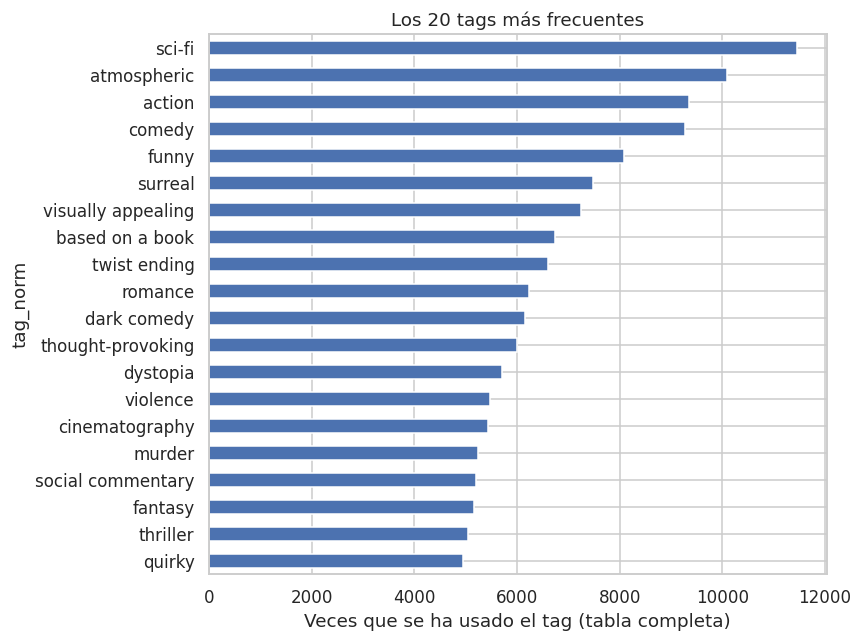

In [10]:
fig, ax = plt.subplots(figsize=(8, 6))
top_tags.sort_values().plot(kind="barh", color="#4C72B0", ax=ax)
ax.set_xlabel("Veces que se ha usado el tag (tabla completa)")
ax.set_title("Los 20 tags más frecuentes")
fig.tight_layout()
plt.show()

**Resultados:** los tags más frecuentes son en su mayoría **géneros escritos como palabra libre**
("sci-fi", "atmospheric", "action", "comedy", "funny") más que opiniones o adjetivos de calidad.

**Conclusión:** buena parte del etiquetado libre reproduce información que el género ya captura —
razón de más para preguntarse en la sección 8.3 si de verdad coinciden, en lugar de asumirlo.

### 8.1 Riqueza de etiquetado vs. popularidad y calidad de calificación

**Qué se calcula:** correlación de **Spearman** entre el número de tags distintos que tiene una
película (exacto) y (a) su número de calificaciones en la muestra, (b) su calificación media.

**Hipótesis:** H₀: ρ = 0, en ambos casos.

In [11]:
rho_pop, p_pop = stats.spearmanr(perfil["n_tags_distintos"], perfil["n_calificaciones"])
rho_rating, p_rating = stats.spearmanr(perfil["n_tags_distintos"], perfil["calificacion_media"])
pruebas["Spearman riqueza de tags ~ popularidad"] = p_pop
pruebas["Spearman riqueza de tags ~ calificación media"] = p_rating

print(f"Riqueza de tags ~ popularidad (n_calificaciones en muestra): rho = {rho_pop:.3f} | p = {p_pop:.2e}")
print(f"Riqueza de tags ~ calificación media:                       rho = {rho_rating:.3f} | p = {p_rating:.2e}")

Riqueza de tags ~ popularidad (n_calificaciones en muestra): rho = 0.683 | p = 0.00e+00
Riqueza de tags ~ calificación media:                       rho = 0.160 | p = 2.55e-121


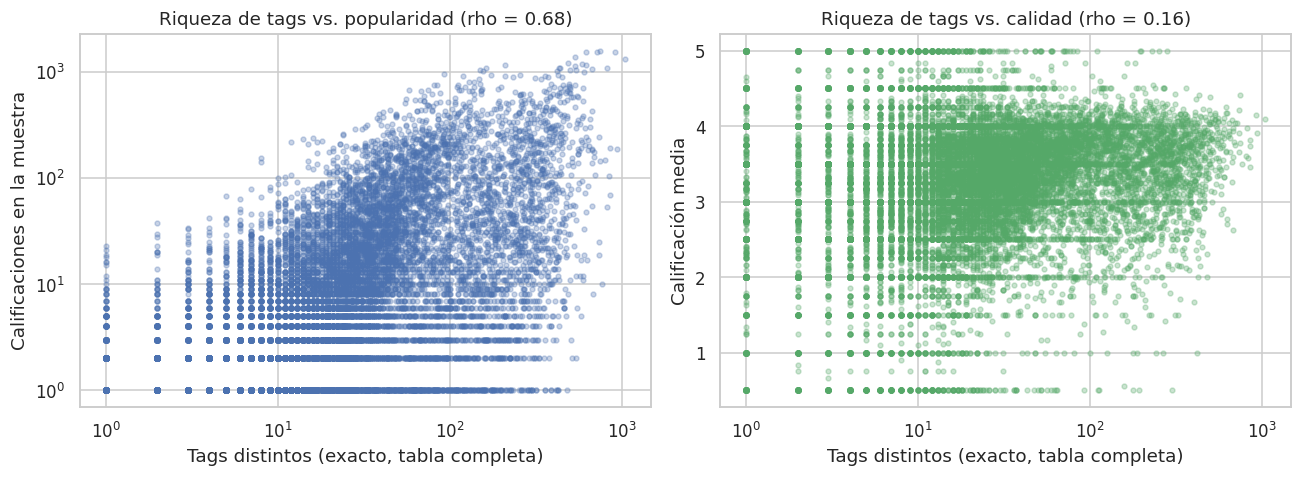

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

ax1.scatter(perfil["n_tags_distintos"], perfil["n_calificaciones"], s=10, alpha=0.3, color="#4C72B0")
ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.set_xlabel("Tags distintos (exacto, tabla completa)")
ax1.set_ylabel("Calificaciones en la muestra")
ax1.set_title(f"Riqueza de tags vs. popularidad (rho = {rho_pop:.2f})")

ax2.scatter(perfil["n_tags_distintos"], perfil["calificacion_media"], s=10, alpha=0.3, color="#55A868")
ax2.set_xscale("log")
ax2.set_xlabel("Tags distintos (exacto, tabla completa)")
ax2.set_ylabel("Calificación media")
ax2.set_title(f"Riqueza de tags vs. calidad (rho = {rho_rating:.2f})")

fig.tight_layout()
plt.show()

**Resultados:** **ρ = 0.683** (p < 0.001) entre riqueza de etiquetado y popularidad — una
asociación fuerte, la más fuerte de todo el notebook. Con la calificación media la asociación es
mucho más débil: **ρ = 0.160** (p < 0.001).

**Conclusión:** tiene sentido que ambas formas de "interacción" con una película —calificarla y
etiquetarla— vayan de la mano: las películas que más gente ve son también las que más gente comenta
con sus propias palabras. Pero comentar mucho una película casi no dice nada sobre si se la califica
alto o bajo: hay películas ampliamente discutidas y etiquetadas que no necesariamente están bien
valoradas.

### 8.2 Cobertura por rango de riqueza de etiquetado

In [13]:
rangos = pd.cut(
    perfil["n_tags_distintos"],
    bins=[-1, 0, 5, 20, 50, perfil["n_tags_distintos"].max()],
    labels=["0 tags", "1-5", "6-20", "21-50", "50+"],
)
resumen_rango = perfil.groupby(rangos, observed=True).agg(
    n_peliculas=("movieId", "size"),
    calificacion_media_promedio=("calificacion_media", "mean"),
    calificaciones_totales_muestra=("n_calificaciones", "sum"),
)
resumen_rango

,n_peliculas,calificacion_media_promedio,calificaciones_totales_muestra
n_tags_distintos,,,
0 tags,2281,2.912363,2749
1-5,4319,3.067126,9016
6-20,7069,3.166574,43708
21-50,3924,3.310873,99895
50+,3686,3.431066,344632


**Resultados:** las 2 281 películas sin ningún tag reúnen muy pocas calificaciones en total dentro
de la muestra, mientras que el pequeño grupo con más de 50 tags distintos concentra una fracción
enorme de las calificaciones totales, con una calificación media notablemente más alta que el resto.

**Conclusión:** confirma de forma descriptiva lo mismo que la correlación de la sección 8.1: la
riqueza de etiquetado funciona como un indicador de qué tan "central" es una película en la
conversación de la plataforma, más que como un indicador de calidad.

### 8.3 ¿Los tags coinciden con el género declarado?

**Qué se calcula:** para tres pares tag-género con relación esperable directa (`funny`↔Comedy,
`scary`↔Horror, `sci-fi`↔Sci-Fi), se compara la proporción de películas etiquetadas con ese tag que
efectivamente tienen ese género, frente a la proporción base de ese género en todo el catálogo. Para
el par `funny`/Comedy se completa con una prueba de **chi-cuadrado de independencia** sobre la tabla de
contingencia (tiene el tag × es del género).

**Hipótesis (chi-cuadrado):** H₀: tener el tag "funny" es independiente de ser género Comedy.

In [14]:
movies_con_genero = movies[~movies["sin_genero"]].copy()

base_comedy = movies_con_genero["genres"].str.contains("Comedy").mean()
base_horror = movies_con_genero["genres"].str.contains("Horror").mean()
base_scifi = movies_con_genero["genres"].str.contains("Sci-Fi").mean()

def proporcion_genero_dado_tag(tag_norm, genero):
    peliculas_con_tag = tags_limpio.loc[tags_limpio["tag_norm"] == tag_norm, "movieId"].unique()
    sub = movies_con_genero[movies_con_genero["movieId"].isin(peliculas_con_tag)]
    return sub["genres"].str.contains(genero).mean(), len(sub)

pares = [("funny", "Comedy", base_comedy), ("scary", "Horror", base_horror), ("sci-fi", "Sci-Fi", base_scifi)]
for tag_norm, genero, base in pares:
    prop, n = proporcion_genero_dado_tag(tag_norm, genero)
    print(f"Tag '{tag_norm}' ({n} películas) -> {prop * 100:.1f}% son género {genero} "
          f"(base en el catálogo: {base * 100:.1f}%)")

Tag 'funny' (1473 películas) -> 78.7% son género Comedy (base en el catálogo: 28.7%)
Tag 'scary' (153 películas) -> 68.6% son género Horror (base en el catálogo: 10.7%)
Tag 'sci-fi' (784 películas) -> 87.8% son género Sci-Fi (base en el catálogo: 6.1%)


In [15]:
peliculas_funny = tags_limpio.loc[tags_limpio["tag_norm"] == "funny", "movieId"].unique()
movies_con_genero["tiene_tag_funny"] = movies_con_genero["movieId"].isin(peliculas_funny)
movies_con_genero["es_comedy"] = movies_con_genero["genres"].str.contains("Comedy")

tabla_contingencia = pd.crosstab(movies_con_genero["tiene_tag_funny"], movies_con_genero["es_comedy"])
chi2, p_chi2, dof, esperado = stats.chi2_contingency(tabla_contingencia)
pruebas["Chi-cuadrado tag 'funny' ~ género Comedy"] = p_chi2

print(tabla_contingencia)
print(f"\nchi2 = {chi2:.1f} | p = {p_chi2:.2e} | grados de libertad = {dof}")

es_comedy        False  True 
tiene_tag_funny              
False            57067  21965
True               314   1159

chi2 = 1826.8 | p = 0.00e+00 | grados de libertad = 1


**Resultados:** el tag "funny" (1 473 películas) coincide con Comedy en el 78.7 % de los casos,
frente a una base de 28.7 % de películas Comedy en todo el catálogo — una diferencia enorme, confirmada
por la prueba de chi-cuadrado (p < 0.001). El mismo patrón aparece con "scary"/Horror (68.6 % frente a
una base de 10.7 %) y con "sci-fi"/Sci-Fi (87.8 % frente a una base de 6.1 %, el salto más grande de
los tres).

**Conclusión:** el etiquetado libre de los usuarios **sí es consistente** con el género declarado por
el catálogo en estos tres casos representativos — la gente que escribe "funny", "scary" o "sci-fi" como
tag está describiendo, con sus propias palabras, casi siempre una película que en efecto pertenece a
ese género. Esto es evidencia (aunque no prueba definitiva, ya que solo se probaron tres pares) de que
el sistema de géneros de MovieLens está razonablemente bien etiquetado y que el texto libre no
contradice sistemáticamente al género oficial.

### 8.4 Tags que distinguen a las películas mejor y peor calificadas

**Qué se calcula:** entre las películas con al menos 30 calificaciones en la muestra (el mismo
umbral usado en `movies_ratings.ipynb`), se dividen en cuartil superior e inferior por calificación
media, y se compara —de forma descriptiva, sin prueba de hipótesis formal— qué proporción de las
películas de cada grupo tiene cada tag, quedándose con los tags donde la diferencia es mayor.

In [16]:
min_calif = 30
candidatas = perfil[perfil["n_calificaciones"] >= min_calif]
q1, q3 = candidatas["calificacion_media"].quantile([0.25, 0.75])
peliculas_top = set(candidatas.loc[candidatas["calificacion_media"] >= q3, "movieId"])
peliculas_bottom = set(candidatas.loc[candidatas["calificacion_media"] <= q1, "movieId"])
print(f"Películas candidatas (>= {min_calif} calificaciones en la muestra): {len(candidatas)}")
print(f"Grupo top (cuartil superior, >= {q3:.2f}): {len(peliculas_top)} películas")
print(f"Grupo bottom (cuartil inferior, <= {q1:.2f}): {len(peliculas_bottom)} películas")

def proporcion_por_tag(peliculas, universo):
    sub = tags_limpio[tags_limpio["movieId"].isin(peliculas)]
    return sub.groupby("tag_norm")["movieId"].nunique() / len(universo)

prop_top = proporcion_por_tag(peliculas_top, peliculas_top)
prop_bottom = proporcion_por_tag(peliculas_bottom, peliculas_bottom)

comparacion = pd.DataFrame({"prop_top": prop_top, "prop_bottom": prop_bottom}).fillna(0)
comparacion["n_top"] = tags_limpio[tags_limpio["movieId"].isin(peliculas_top)].groupby("tag_norm")["movieId"].nunique().reindex(comparacion.index).fillna(0)
comparacion["n_bottom"] = tags_limpio[tags_limpio["movieId"].isin(peliculas_bottom)].groupby("tag_norm")["movieId"].nunique().reindex(comparacion.index).fillna(0)
comparacion = comparacion[(comparacion["n_top"] + comparacion["n_bottom"]) >= 15]
comparacion["diferencia"] = comparacion["prop_top"] - comparacion["prop_bottom"]

print("\nTags más asociados a películas BIEN calificadas:")
display(comparacion.sort_values("diferencia", ascending=False).head(10)[["prop_top", "prop_bottom", "diferencia"]].round(3))
print("\nTags más asociados a películas MAL calificadas:")
display(comparacion.sort_values("diferencia").head(10)[["prop_top", "prop_bottom", "diferencia"]].round(3))

Películas candidatas (>= 30 calificaciones en la muestra): 3018
Grupo top (cuartil superior, >= 3.79): 755 películas
Grupo bottom (cuartil inferior, <= 3.17): 755 películas



Tags más asociados a películas BIEN calificadas:


,prop_top,prop_bottom,diferencia
tag_norm,,,
imdb top 250,0.332,0.000,0.332
tumey's dvds,0.321,0.017,0.303
drama,0.335,0.046,0.289
atmospheric,0.257,0.025,0.232
classic,0.269,0.044,0.225
bd-r,0.264,0.040,0.224
oscar nominee: best picture,0.221,0.003,0.219
national film registry,0.203,0.001,0.201
overrated,0.220,0.025,0.195



Tags más asociados a películas MAL calificadas:


,prop_top,prop_bottom,diferencia
tag_norm,,,
sequel,0.058,0.187,-0.128
stupid,0.037,0.127,-0.090
franchise,0.042,0.105,-0.062
campy,0.023,0.075,-0.053
helicopter,0.053,0.105,-0.052
action,0.156,0.207,-0.050
silly,0.048,0.098,-0.050
nostalgia critic,0.000,0.044,-0.044
remake,0.029,0.073,-0.044


**Resultados:** entre las mejor calificadas destacan tags "curatoriales" — `imdb top 250`,
`national film registry`, `oscar nominee: best picture`, `classic`, `cinematography`, `atmospheric` —
es decir, reconocimiento externo y vocabulario de crítica de cine. Curiosamente, `overrated` también es
mucho más frecuente en el grupo bien calificado (22.0 % frente a 2.5 %): solo tiene sentido tildar de
"sobrevalorada" a una película que, para empezar, tiene una reputación alta que cuestionar. Entre las
peor calificadas dominan `sequel`, `stupid`, `franchise`, `campy`, `silly`, `remake` y `superhero` —
vocabulario que apunta a continuaciones comerciales poco logradas.

**Conclusión:** el lenguaje libre de los usuarios distingue con bastante claridad entre "cine
consagrado" y "producto de franquicia menor", y lo hace de forma consistente con la calificación
numérica — otra pieza de evidencia de que el etiquetado de MovieLens es información genuina y no ruido
aleatorio. Esta comparación es descriptiva (no se corrigió por comparaciones múltiples porque no se
fijó de antemano una lista cerrada de tags a probar, sino que se exploraron todos); no debe leerse como
una lista de causas de la buena o mala calificación, solo como palabras que covarían con ella.

## 9. Corrección por comparaciones múltiples

**Qué se calcula:** el ajuste de **Holm-Bonferroni** sobre los p-valores de las pruebas
predefinidas de antemano: las dos correlaciones de la sección 8.1 y la prueba de chi-cuadrado de la
sección 8.3. (La comparación de tags de la sección 8.4 queda fuera porque fue exploratoria, no una
lista de hipótesis fijada antes de ver los datos — mezclarla aquí daría una falsa sensación de rigor).

In [17]:
ajustados = holm(pruebas)
tabla_pruebas = pd.DataFrame({
    "p_original": pd.Series(pruebas),
    "p_ajustado_holm": pd.Series(ajustados),
})
tabla_pruebas["significativo_5%"] = np.where(tabla_pruebas["p_ajustado_holm"] < 0.05, "sí", "no")
tabla_pruebas.sort_values("p_original").round(6)

,p_original,p_ajustado_holm,significativo_5%
Chi-cuadrado tag 'funny' ~ género Comedy,0.0,0.0,sí
Spearman riqueza de tags ~ popularidad,0.0,0.0,sí
Spearman riqueza de tags ~ calificación media,0.0,0.0,sí


**Resultados:** las tres pruebas predefinidas siguen siendo significativas tras el ajuste.

**Conclusión:** con solo tres pruebas planeadas de antemano, la corrección apenas cambia los
p-valores — es con las comparaciones múltiples masivas (como las 19 de `movies_ratings.ipynb`) donde
Holm realmente importa. Lo relevante aquí no es tanto el ajuste en sí, sino la disciplina de separar
lo que se planeó probar de lo que se exploró después de ver los datos.

## 10. Conclusiones y limitaciones

### Conclusiones

1. **`tags.csv` es una tabla completa, real y prácticamente limpia:** solo 17 filas nulas de 2 millones,
   sin duplicados exactos.
2. **La riqueza de etiquetado se asocia fuertemente con la popularidad** (ρ = 0.68, exacta del lado de
   los tags) **pero débilmente con la calidad** (ρ = 0.16): comentar mucho una película no implica
   calificarla bien.
3. **El etiquetado libre es consistente con el género declarado:** los tags "funny", "scary" y
   "sci-fi" coinciden con su género correspondiente en 69-88 % de los casos, muy por encima de la base
   del catálogo — evidencia de que el género de MovieLens está razonablemente bien asignado.
4. **El vocabulario de las etiquetas distingue cine consagrado de producto de franquicia:** tags como
   "imdb top 250" o "national film registry" marcan a las películas mejor calificadas; "sequel",
   "stupid" y "franchise", a las peor calificadas.

### Limitaciones

* **Doble fuente de incertidumbre:** `tags.csv` es exacto, pero todo lo que involucra calificaciones
  viene de la muestra del 1.56 % — las correlaciones de la sección 8.1 mezclan una variable exacta con
  una estimada.
* **Solo se probaron tres pares tag-género** en la sección 8.3, elegidos por tener una correspondencia
  obvia; no se puede generalizar a "todos los tags coinciden con su género" sin probar una muestra más
  amplia y representativa de pares.
* **La comparación de tags por calidad (sección 8.4) es exploratoria y descriptiva**, sin prueba de
  hipótesis formal ni corrección por comparaciones múltiples — se probaron implícitamente todos los
  tags con suficiente presencia, así que algunas de las diferencias más pequeñas de la lista podrían
  ser ruido.
* **El texto libre no está corregido ortográficamente**: variantes de escritura más allá de
  mayúsculas/espacios (errores tipográficos, sinónimos) no se fusionaron, así que la riqueza de
  etiquetado real de algunas películas podría estar ligeramente subestimada.